In [1]:
from helpers import init, preprocess_data
import optuna
from optuna.trial import TrialState

In [2]:
SEED = 42
X_train_raw, y_train_cm, X_val_raw, y_val_cm, ROOT = init(SEED)
X_train, y_train, X_val, y_val, target_min_cm, target_range_cm, rss_scale = preprocess_data(X_train_raw, y_train_cm, X_val_raw, y_val_cm)

storage_loc = "sqlite:///trail_1.db"

PyTorch: 2.11.0+cu130
Training rows: 42166
Validation rows: 4685
Input shape: (42166, 9)
Target x range (cm): 0.0 to 281.0
Target y range (cm): 0.0 to 275.0
Using split files:
  train: train_clean_3x3_1cm.csv 42166 rows
  validation: validation_clean_3x3_1cm.csv 4685 rows
RSS scale: 0.8493868112564087
Target min cm: [0. 0.]
Target range cm: [281. 275.]


# Get the model

In [3]:
from vlp_hackathon.baseline_model import BaselineMLP
from vlp_hackathon.improved_model import ImprovedMLP
model_cls = ImprovedMLP

# Run a trail

In [4]:
from torch import nn
import torch
import numpy as np
from matplotlib import pyplot as plt
import copy

def train_model(model, optimizer, loss_fn, epochs, batch_size, plot: bool = False, ret_model: bool = False, lr_scheduler=None):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    X_train_t = torch.from_numpy(X_train).to(device)
    y_train_t = torch.from_numpy(y_train).to(device)
    X_val_t = torch.from_numpy(X_val).to(device)
    y_val_t = torch.from_numpy(y_val).to(device)
    model = model.to(device)

    history = []
    best_model = copy.deepcopy(model)
    lowest_loss = float("inf")
    train_rng = np.random.default_rng(SEED)
    for epoch in range(epochs):
        model.train()
        permutation = train_rng.permutation(len(X_train))
        running = 0.0
        for start in range(0, len(permutation), batch_size):
            idx = permutation[start:start + batch_size]
            xb = X_train_t[idx]
            yb = y_train_t[idx]
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            if loss < lowest_loss:
                best_model = copy.deepcopy(model)
            optimizer.step()
            running += float(loss.item()) * len(idx)

        model.eval()
        with torch.no_grad():
            val_loss = float(loss_fn(model(X_val_t), y_val_t).item())
        history.append((running / len(X_train), val_loss))
        if lr_scheduler:
            lr_scheduler.step()
        print(f"epoch={epoch + 1:02d} train_mse={history[-1][0]:.6f} val_mse={val_loss:.6f}")

    history = np.asarray(history, dtype=np.float32)
    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(history[:, 0], label="train")
        plt.plot(history[:, 1], label="validation")
        plt.xlabel("Epoch")
        plt.ylabel("MSE on normalized coordinates")
        plt.legend()
        plt.title("Baseline training curve")
        plt.show()

    if ret_model:
        return best_model
    return np.min(history[:, 1])

def run_trial(trial):
    epochs = 40

    print(trial)
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_int("batch_size", 16, 4096)

    depth = trial.suggest_int("depth", 1, 6)
    layers = []
    for layer in range(depth):
        width = trial.suggest_int(f"layer_{layer}", 2, 128)
        layers.append(width)

    # Start and end are fixed
    layers = [9] + layers + [2]

    act = trial.suggest_categorical("act", ["relu", "tanh", "sigmoid", ""])
    last_act = trial.suggest_categorical("last_act", ["relu", "tanh", "sigmoid", ""])
    layer_norm = trial.suggest_categorical("layer_norm", [True, False])

    model = model_cls(layers=layers, activation=act, last_act=last_act, layer_norm=layer_norm)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    return train_model(model, optimizer, loss_fn, epochs, batch_size)

In [ ]:
study = optuna.create_study(direction='minimize', study_name="task_1", load_if_exists=True, storage=storage_loc)
study.optimize(run_trial, n_trials=5000, show_progress_bar=True)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))
print("  Number of pruned trials: ", len(pruned_trials))
print("  Number of complete trials: ", len(complete_trials))

print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2026-07-08 17:48:10,638] A new study created in RDB with name: task_1


  0%|          | 0/5000 [00:00<?, ?it/s]

Sequential(
  (0): Linear(in_features=9, out_features=90, bias=True)
  (1): LayerNorm((90,), eps=1e-05, elementwise_affine=True)
  (2): ReLU()
  (3): Linear(in_features=90, out_features=122, bias=True)
  (4): LayerNorm((122,), eps=1e-05, elementwise_affine=True)
  (5): ReLU()
  (6): Linear(in_features=122, out_features=98, bias=True)
  (7): LayerNorm((98,), eps=1e-05, elementwise_affine=True)
  (8): ReLU()
  (9): Linear(in_features=98, out_features=15, bias=True)
  (10): LayerNorm((15,), eps=1e-05, elementwise_affine=True)
  (11): ReLU()
  (12): Linear(in_features=15, out_features=84, bias=True)
  (13): LayerNorm((84,), eps=1e-05, elementwise_affine=True)
  (14): ReLU()
  (15): Linear(in_features=84, out_features=99, bias=True)
  (16): LayerNorm((99,), eps=1e-05, elementwise_affine=True)
  (17): ReLU()
  (18): Linear(in_features=99, out_features=2, bias=True)
  (19): Tanh()
)
epoch=01 train_mse=0.090547 val_mse=0.041962
epoch=02 train_mse=0.024394 val_mse=0.012169
epoch=03 train_mse=0.

In [5]:
study = optuna.load_study(study_name="task_1", storage=storage_loc)

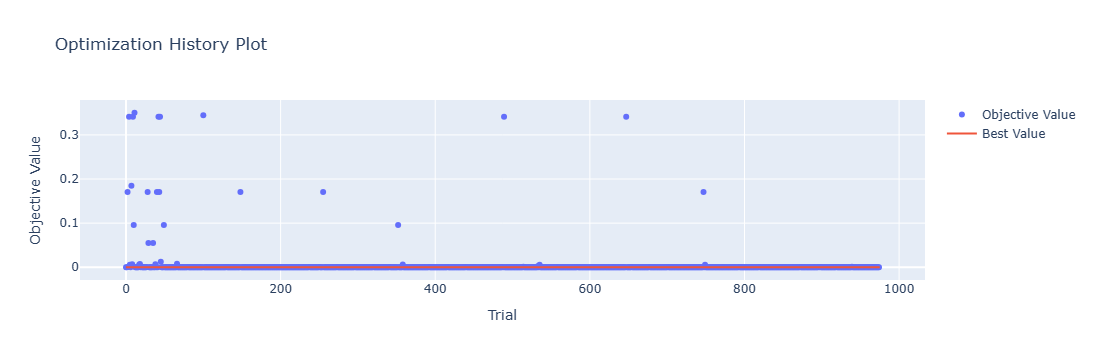

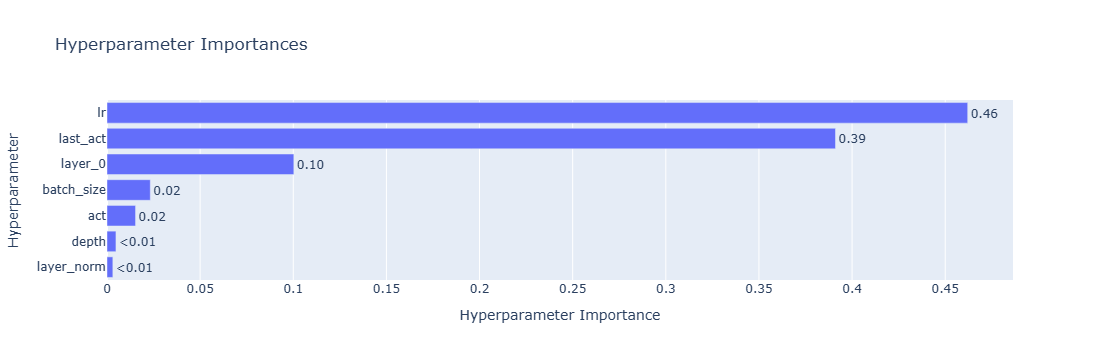

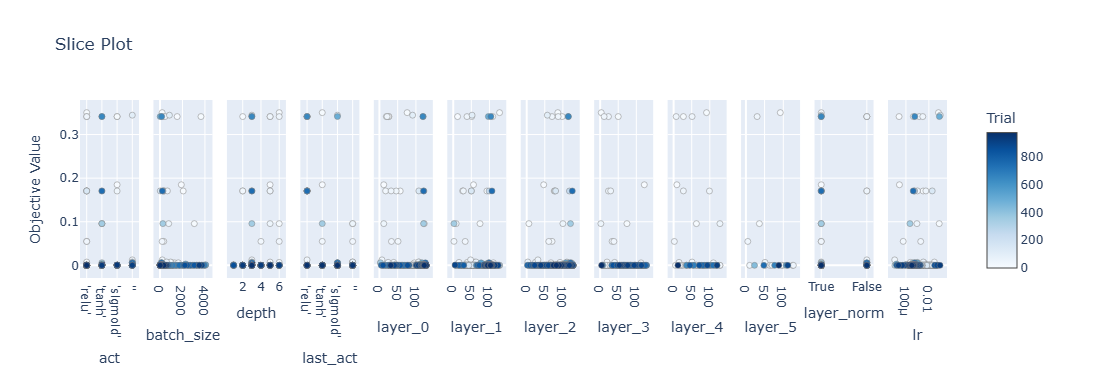

In [7]:
from plotly.io import show

fig = optuna.visualization.plot_optimization_history(study)
show(fig)

fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig = optuna.visualization.plot_slice(study)
show(fig)

# Make the best model

{'lr': 0.0007162658219547872, 'batch_size': 20, 'depth': 3, 'layer_0': 126, 'layer_1': 100, 'layer_2': 121, 'act': 'tanh', 'last_act': 'sigmoid', 'layer_norm': True}
Sequential(
  (0): Linear(in_features=9, out_features=126, bias=True)
  (1): LayerNorm((126,), eps=1e-05, elementwise_affine=True)
  (2): Tanh()
  (3): Linear(in_features=126, out_features=100, bias=True)
  (4): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
  (5): Tanh()
  (6): Linear(in_features=100, out_features=121, bias=True)
  (7): LayerNorm((121,), eps=1e-05, elementwise_affine=True)
  (8): Tanh()
  (9): Linear(in_features=121, out_features=2, bias=True)
  (10): Sigmoid()
)
epoch=01 train_mse=0.000771 val_mse=0.000082
epoch=02 train_mse=0.000110 val_mse=0.000068
epoch=03 train_mse=0.000073 val_mse=0.000061
epoch=04 train_mse=0.000060 val_mse=0.000049
epoch=05 train_mse=0.000049 val_mse=0.000035
epoch=06 train_mse=0.000041 val_mse=0.000034
epoch=07 train_mse=0.000035 val_mse=0.000040
epoch=08 train_mse=0.00002

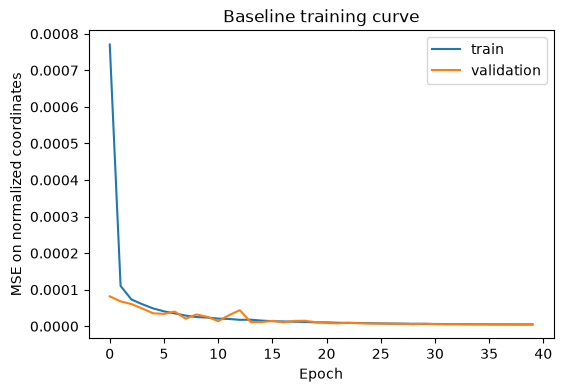

In [6]:
best_params = study.best_params
print(best_params)

layers = []
for layer_idx in range(best_params["depth"]):
    layer_name = f"layer_{layer_idx}"
    layer_size = best_params[layer_name]
    layers.append(layer_size)
layers = [9] + layers + [2]
best_model = model_cls(layers=layers, activation=best_params["act"], last_act=best_params["last_act"])

epochs = 40
batch_size = best_params["batch_size"]
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"])
loss_fn = nn.MSELoss()

# Without lr_scheduler: val_mse=0.000007 @ epoch 36
# Float validation mean error:   1.028 cm
# Float validation median error: 0.927 cm
# Float validation p95 error:    2.108 cm
# With lr scheduler:
# Float validation mean error:   0.706 cm
# Float validation median error: 0.608 cm
# Float validation p95 error:    1.536 cm
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_model = train_model(best_model, optimizer, loss_fn, epochs, batch_size, plot=True, ret_model=True, lr_scheduler=lr_scheduler)

# Make the baseline model

epoch=01 train_mse=0.082612 val_mse=0.052448
epoch=02 train_mse=0.023454 val_mse=0.007999
epoch=03 train_mse=0.007465 val_mse=0.006276
epoch=04 train_mse=0.006202 val_mse=0.005332
epoch=05 train_mse=0.005255 val_mse=0.004486
epoch=06 train_mse=0.004381 val_mse=0.003716
epoch=07 train_mse=0.003601 val_mse=0.003040
epoch=08 train_mse=0.002964 val_mse=0.002529
epoch=09 train_mse=0.002449 val_mse=0.002053
epoch=10 train_mse=0.001906 val_mse=0.001559
epoch=11 train_mse=0.001463 val_mse=0.001231
epoch=12 train_mse=0.001189 val_mse=0.001039
epoch=13 train_mse=0.001012 val_mse=0.000899
epoch=14 train_mse=0.000872 val_mse=0.000775
epoch=15 train_mse=0.000766 val_mse=0.000689
epoch=16 train_mse=0.000685 val_mse=0.000620
epoch=17 train_mse=0.000621 val_mse=0.000565
epoch=18 train_mse=0.000567 val_mse=0.000519
epoch=19 train_mse=0.000522 val_mse=0.000481
epoch=20 train_mse=0.000482 val_mse=0.000439
epoch=21 train_mse=0.000447 val_mse=0.000409
epoch=22 train_mse=0.000418 val_mse=0.000381
epoch=23 t

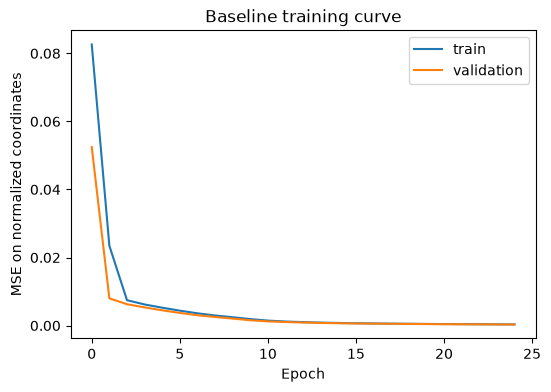

In [9]:
original_model = BaselineMLP(input_features=9)
history = []
epochs = 25
batch_size = 512
optimizer = torch.optim.Adam(original_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
original_model = train_model(original_model, optimizer, loss_fn, epochs, batch_size, plot=True, ret_model=True)

# Compare performance


original:
Float validation mean error:   5.428 cm
Float validation median error: 4.208 cm
Float validation p95 error:    14.914 cm

best:
Float validation mean error:   0.706 cm
Float validation median error: 0.608 cm
Float validation p95 error:    1.536 cm


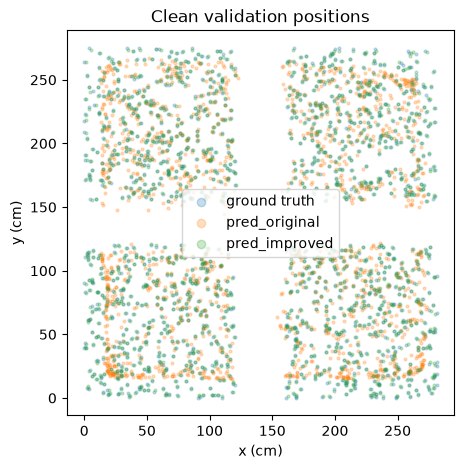

In [10]:
from vlp_hackathon.metrics import euclidean_errors_cm

def eval_model(model, name: str):
    model.eval()
    with torch.no_grad():
        float_norm = model(torch.from_numpy(X_val)).numpy()
    float_pred_cm = target_min_cm + float_norm * target_range_cm
    float_errors = euclidean_errors_cm(float_pred_cm, y_val_cm)

    print(f"\n{name}:")
    print(f"Float validation mean error:   {float_errors.mean():.3f} cm")
    print(f"Float validation median error: {np.median(float_errors):.3f} cm")
    print(f"Float validation p95 error:    {np.percentile(float_errors, 95):.3f} cm")
    return float_pred_cm

errors = []
for model, name in [(original_model, "original"), (best_model, "best")]:
    errors.append(eval_model(model, name))

plt.figure(figsize=(5, 5))
n_show = min(1500, len(y_val_cm))
plt.scatter(y_val_cm[:n_show, 0], y_val_cm[:n_show, 1], s=4, alpha=0.25, label="ground truth")
plt.scatter(errors[0][:n_show, 0], errors[0][:n_show, 1], s=4, alpha=0.25, label="pred_original")
plt.scatter(errors[1][:n_show, 0], errors[1][:n_show, 1], s=4, alpha=0.25, label="pred_improved")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.legend(markerscale=3)
plt.title("Clean validation positions")
plt.show()

# Save model

In [9]:
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)
torch.save(best_model.state_dict(), models_dir / "best_task1.pt")
np.savez(
    models_dir / "best_task1_scaling.npz",
    rss_scale=np.asarray(rss_scale, dtype=np.float32),
    target_min_cm=target_min_cm.astype(np.float32),
    target_range_cm=target_range_cm.astype(np.float32),
    train_loss=np.zeros((0,)),
    float_errors=np.zeros((0,)),
)
print("Saved trained state and scaling constants")

import subprocess
import sys

export_command = [
    sys.executable,
    str(ROOT / "scripts" / "export_litert_baseline.py"),
]

print("Running LiteRT export helper:")
print(" ".join(export_command))

subprocess.run(
    export_command,
    cwd=ROOT,
    check=True,
)

tflite_path = ROOT / "models" / "best_task1.tflite"
assert tflite_path.exists(), f"Export completed but {tflite_path} was not created."

print("TFLite bytes:", tflite_path.stat().st_size)

Saved trained state and scaling constants
Running LiteRT export helper:
/home/lucan/projects/vlc_hackaton/.venv/bin/python /home/lucan/projects/vlc_hackaton/scripts/export_litert_baseline.py


I0000 00:00:1783587754.427107 2387387 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(00:00) [START] LiteRT-Torch Convert
(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default
(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > 
ExportedProgram Run Decompositions


/home/lucan/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default (+00:00)
(00:00) [START] LiteRT-Torch Convert > Run FX Passes
(00:01) [START] LiteRT-Torch Convert > Run FX Passes > ExportedProgram Run 
Decompositions
(00:01) [ DONE] LiteRT-Torch Convert > Run FX Passes > ExportedProgram Run 
Decompositions (+00:00)
(00:01) [ DONE] LiteRT-Torch Convert > Run FX Passes (+00:00)
(00:01) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default
(00:01) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions


/home/lucan/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/home/lucan/projects/vlc_hackaton/.venv/lib/python3.12/site-packages/litert_torch/_convert/signature.py:52: FutureWarning: `treespec.children_specs` is deprecated. Use `treespec.child(index)` to access a single child, or `treespec.children()` to get all children.
  args_spec, kwargs_spec = spec.children_specs
/home/lucan/projects/vlc_hackaton/.venv/lib/python3.12/site-packages/litert_torch/_convert/signature.py:58: FutureWarning: `treespec.children_specs` is deprecated. Use `treespec.child(index)` to access a single child, or `treespec.children()` to get all children.
  kwargs_spec.children_specs, kwargs_spec.context


(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:01) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions
(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:01) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create 
MLIR Module
(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create 
MLIR Module (+00:00)
(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default (+00:00)
(00:01) [START] LiteRT-Torch Convert > Merge MLIR Modules
(00:01) [ DONE] LiteRT-Torch Convert > Merge MLIR Modules (+00:00)
(00:01) [START] LiteRT-Torch Convert > Run LiteRT Converter Passes
(00:01) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)
(00:01) [ DONE] LiteRT-Torch Convert (+00:01)
(00:00) [START] Write Model to Bytes
(00:00) [ DONE] Write Model to Byte

I0000 00:00:1783587757.978093 2387387 flatbuffer_export.cc:4346] Estimated count of arithmetic ops: 2946  ops, equivalently 1473  MACs


AssertionError: Export completed but /home/lucan/projects/vlc_hackaton/models/best_task1.tflite was not created.